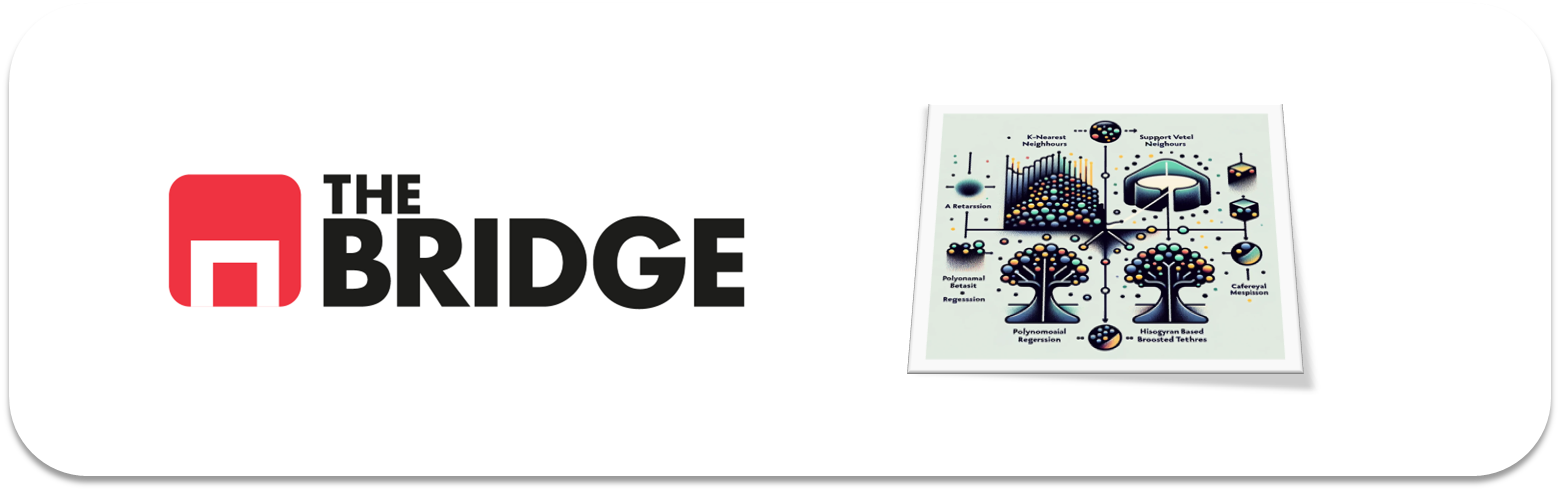

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    mean_absolute_percentage_error, mean_squared_error
)
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold, KFold
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [3]:
# El dataset usa '|' como separador
df = pd.read_csv("data/wines_dataset.csv", sep="|")

print(f"Dimensiones: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
df.head()

Dimensiones: (6497, 13)

Columnas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'class']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [4]:
df.info()
print()
df.describe().round(3)

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492,5.818
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193,0.873
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000,3.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500,5.000
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300,6.000
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300,6.000
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900,9.000


In [5]:
target_clf = "quality"
target_reg = "alcohol"

print("=" * 45)
print(f"Target clasificación: {target_clf}")
print("Distribución de calidades:")
print(df[target_clf].value_counts().sort_index())
print(f"\nTarget regresión: {target_reg}")
print(df[target_reg].describe())

Target clasificación: quality
Distribución de calidades:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Target regresión: alcohol
count    6497.000000
mean       10.491801
std         1.192712
min         8.000000
25%         9.500000
50%        10.300000
75%        11.300000
max        14.900000
Name: alcohol, dtype: float64


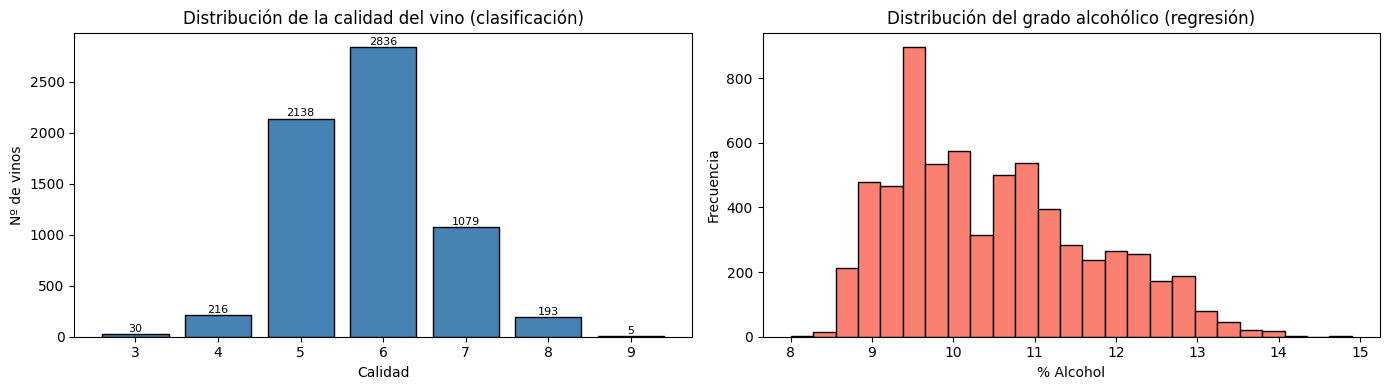

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

q_counts = df[target_clf].value_counts().sort_index()
axes[0].bar(q_counts.index, q_counts.values, color="steelblue", edgecolor="black")
axes[0].set_title("Distribución de la calidad del vino (clasificación)")
axes[0].set_xlabel("Calidad")
axes[0].set_ylabel("Nº de vinos")
for i, v in zip(q_counts.index, q_counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontsize=8)

axes[1].hist(df[target_reg], bins=25, color="salmon", edgecolor="black")
axes[1].set_title("Distribución del grado alcohólico (regresión)")
axes[1].set_xlabel("% Alcohol")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

**Assessment previo:**

**Clasificación (quality):**
El target tiene 7 clases (de 3 a 9) pero la distribución está muy concentrada en las notas 5, 6 y 7. Las clases extremas (3 y 9) tienen muy pocos ejemplos (30 y 5 casos respectivamente), lo que hará muy difícil que el modelo las aprenda bien.
La métrica objetivo es el **recall macro** como pide el cliente (clasificar bien en media).
Vamos a tener que usar `class_weight='balanced'` para intentar compensar el desequilibrio.

**Regresión (alcohol):**
La distribución del grado alcohólico tiene una forma bastante razonable con media ~10.5%.
La métrica que pide el cliente es el error porcentual → usaremos **MAPE**.
Este problema parece más manejable que la clasificación multiclase.

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [7]:
# Preparación de datos para clasificación
df_clf = df.copy()

# La columna 'class' es categórica (red/white) → la codificamos con get_dummies
df_clf = pd.get_dummies(df_clf, columns=["class"], drop_first=True, dtype=int)
print("Columnas tras encoding:", list(df_clf.columns))

# Split estratificado para mantener la proporción de las clases minoritarias
X_clf = df_clf.drop(target_clf, axis=1)
y_clf = df_clf[target_clf]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Escalado (obligatorio para KNN y LR)
scaler_clf = StandardScaler()
X_train_clf = pd.DataFrame(
    scaler_clf.fit_transform(X_train_clf),
    columns=X_train_clf.columns
)
X_test_clf = pd.DataFrame(
    scaler_clf.transform(X_test_clf),
    columns=X_test_clf.columns
)

print(f"Train: {X_train_clf.shape}  |  Test: {X_test_clf.shape}")
print(f"\nDistribución del target en train:")
print(y_train_clf.value_counts().sort_index())

Columnas tras encoding: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'class_white']
Train: (5197, 12)  |  Test: (1300, 12)

Distribución del target en train:
quality
3      24
4     173
5    1710
6    2269
7     863
8     154
9       4
Name: count, dtype: int64


In [8]:
# Comparación de modelos con validación cruzada (recall macro)
# KNN baseline con dos valores de K
knn3 = KNeighborsClassifier(n_neighbors=3)
knn7 = KNeighborsClassifier(n_neighbors=7)

# class_weight='balanced' para compensar el desequilibrio de clases
lr   = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
rf   = RandomForestClassifier(n_estimators=100, max_depth=10,
                              class_weight="balanced", random_state=42)

modelos_clf = {
    "KNN (k=3)":           knn3,
    "KNN (k=7)":           knn7,
    "Logistic Regression": lr,
    "Random Forest":       rf
}

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_clf = {}

print("Comparativa de modelos (Recall Macro, 5-fold CV):\n")
for nombre, modelo in modelos_clf.items():
    scores = cross_val_score(modelo, X_train_clf, y_train_clf,
                             cv=cv_clf, scoring="recall_macro")
    resultados_clf[nombre] = scores
    print(f"  {nombre:22s}: {scores.mean():.4f} ± {scores.std():.4f}")

Comparativa de modelos (Recall Macro, 5-fold CV):



c:\Users\csancho\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\csancho\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


  KNN (k=3)             : 0.3238 ± 0.0274
  KNN (k=7)             : 0.2774 ± 0.0217


c:\Users\csancho\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\csancho\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\csancho\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


  Logistic Regression   : 0.3909 ± 0.0553
  Random Forest         : 0.3702 ± 0.0310


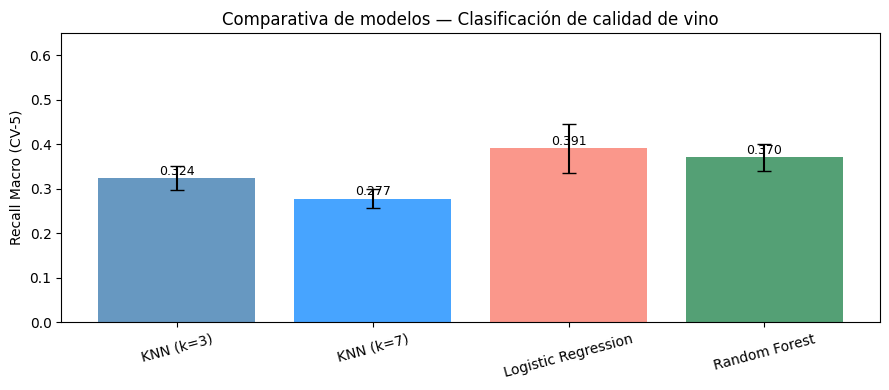


Mejor modelo: Logistic Regression (recall macro = 0.3909)


In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
nombres = list(resultados_clf.keys())
medias  = [resultados_clf[n].mean() for n in nombres]
stds    = [resultados_clf[n].std()  for n in nombres]
colors  = ["steelblue", "dodgerblue", "salmon", "seagreen"]
bars = ax.bar(nombres, medias, yerr=stds, capsize=5, color=colors, alpha=0.82)
ax.set_ylabel("Recall Macro (CV-5)")
ax.set_title("Comparativa de modelos — Clasificación de calidad de vino")
ax.set_ylim(0, 0.65)
for bar, m in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{m:.3f}", ha="center", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

mejor_clf = max(resultados_clf, key=lambda k: resultados_clf[k].mean())
print(f"\nMejor modelo: {mejor_clf} (recall macro = {resultados_clf[mejor_clf].mean():.4f})")

In [10]:
# Optimización de hiperparámetros — Random Forest (mejor en CV)
param_grid_clf = {
    "n_estimators":     [100, 200],
    "max_depth":        [8, 15, None],
    "min_samples_leaf": [1, 3]
}

gs_clf = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid_clf,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="recall_macro",
    n_jobs=-1,
    verbose=1
)
gs_clf.fit(X_train_clf, y_train_clf)

print("Mejores parámetros:")
for k, v in gs_clf.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor recall macro en CV: {gs_clf.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores parámetros:
  max_depth: 15
  min_samples_leaf: 3
  n_estimators: 200

Mejor recall macro en CV: 0.3560


In [11]:
# Evaluación en test
y_pred_clf = gs_clf.best_estimator_.predict(X_test_clf)

print("=" * 55)
print("EVALUACIÓN EN TEST — Clasificación de calidad")
print("=" * 55)
print(classification_report(y_test_clf, y_pred_clf))

EVALUACIÓN EN TEST — Clasificación de calidad
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.43      0.23      0.30        43
           5       0.69      0.75      0.72       428
           6       0.67      0.65      0.66       567
           7       0.56      0.63      0.59       216
           8       0.58      0.36      0.44        39
           9       0.00      0.00      0.00         1

    accuracy                           0.65      1300
   macro avg       0.42      0.37      0.39      1300
weighted avg       0.65      0.65      0.65      1300



c:\Users\csancho\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\csancho\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\csancho\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

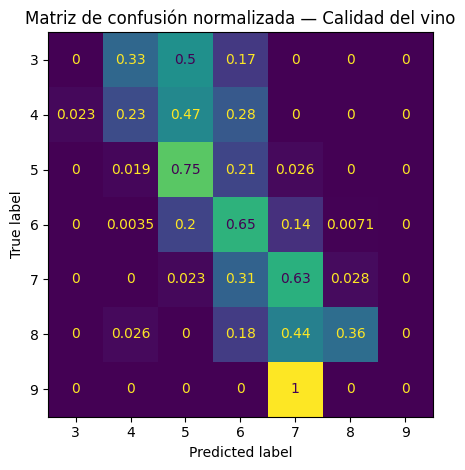

In [12]:
# Matriz de confusión normalizada por recall (filas)
ConfusionMatrixDisplay.from_predictions(
    y_test_clf, y_pred_clf,
    normalize="true",
    colorbar=False
)
plt.title("Matriz de confusión normalizada — Calidad del vino")
plt.tight_layout()
plt.show()

**Análisis de errores — Clasificación:**

Como era de esperar dado el fuerte desbalanceo, el modelo tiene muchas dificultades con las clases extremas (3 y 9), que prácticamente no consigue detectar porque hay muy pocos ejemplos de entrenamiento.

Las clases centrales (5, 6, 7) se predicen con algo más de éxito pero hay mucha confusión entre ellas, lo cual es lógico ya que la diferencia entre un vino de calidad 5 y uno de calidad 6 puede ser subjetiva.

**Posibles mejoras:**
- Reagrupar las clases: juntar 3+4 en 'baja calidad' y 8+9 en 'alta calidad' reduciría el problema a 3 clases más equilibradas
- Aplicar SMOTE multiclase para las clases 3, 4, 8 y 9
- Explorar más a fondo las features más correlacionadas con la calidad

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [13]:
# Preparación de datos para regresión
# Reutilizamos el encoding de 'class' del paso anterior
df_reg = df.copy()
df_reg = pd.get_dummies(df_reg, columns=["class"], drop_first=True, dtype=int)

# Para regresión el target es 'alcohol' y usamos el resto como features
# (incluyendo quality y class_white tal como indica el enunciado)
X_reg = df_reg.drop(target_reg, axis=1)
y_reg = df_reg[target_reg]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Escalado
scaler_reg = StandardScaler()
X_train_reg = pd.DataFrame(
    scaler_reg.fit_transform(X_train_reg),
    columns=X_train_reg.columns
)
X_test_reg = pd.DataFrame(
    scaler_reg.transform(X_test_reg),
    columns=X_test_reg.columns
)

print(f"Train: {X_train_reg.shape}  |  Test: {X_test_reg.shape}")

Train: (5197, 12)  |  Test: (1300, 12)


In [14]:
# Comparativa de modelos de regresión
# Métrica: MAPE (el cliente quiere error porcentual sobre el grado real)
lr_reg  = LinearRegression()
ridge   = Ridge(alpha=1.0)
knn_reg = KNeighborsRegressor(n_neighbors=5)
rf_reg  = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

modelos_reg = {
    "Linear Regression": lr_reg,
    "Ridge":             ridge,
    "KNN Regressor":     knn_reg,
    "Random Forest":     rf_reg
}

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
resultados_reg = {}

print("Comparativa de modelos (MAPE, 5-fold CV):\n")
for nombre, modelo in modelos_reg.items():
    scores = cross_val_score(modelo, X_train_reg, y_train_reg,
                             cv=cv_reg,
                             scoring="neg_mean_absolute_percentage_error")
    mape = -scores.mean() * 100
    std  = scores.std()  * 100
    resultados_reg[nombre] = -scores
    print(f"  {nombre:22s}: MAPE = {mape:.2f}% ± {std:.2f}%")

Comparativa de modelos (MAPE, 5-fold CV):

  Linear Regression     : MAPE = 3.37% ± 0.06%
  Ridge                 : MAPE = 3.37% ± 0.06%
  KNN Regressor         : MAPE = 4.20% ± 0.07%
  Random Forest         : MAPE = 3.06% ± 0.04%


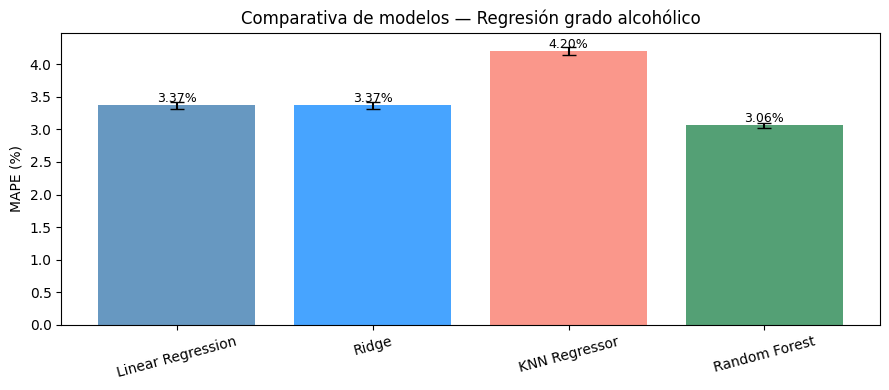


Mejor modelo: Random Forest con MAPE = 3.06%


In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
nombres = list(resultados_reg.keys())
medias  = [resultados_reg[n].mean() * 100 for n in nombres]
stds    = [resultados_reg[n].std()  * 100 for n in nombres]
colors  = ["steelblue", "dodgerblue", "salmon", "seagreen"]
bars = ax.bar(nombres, medias, yerr=stds, capsize=5, color=colors, alpha=0.82)
ax.set_ylabel("MAPE (%)")
ax.set_title("Comparativa de modelos — Regresión grado alcohólico")
for bar, m in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{m:.2f}%", ha="center", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

mejor_reg = min(resultados_reg, key=lambda k: resultados_reg[k].mean())
print(f"\nMejor modelo: {mejor_reg} con MAPE = {resultados_reg[mejor_reg].mean()*100:.2f}%")

In [16]:
# Optimización hiperparámetros — Random Forest Regressor
param_grid_reg = {
    "n_estimators":     [100, 200],
    "max_depth":        [10, 20, None],
    "min_samples_leaf": [1, 3]
}

gs_reg = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_reg,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1
)
gs_reg.fit(X_train_reg, y_train_reg)

print("Mejores parámetros:")
for k, v in gs_reg.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor MAPE en CV: {-gs_reg.best_score_*100:.2f}%")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores parámetros:
  max_depth: None
  min_samples_leaf: 1
  n_estimators: 200

Mejor MAPE en CV: 2.80%


In [17]:
# Evaluación en test
y_pred_reg = gs_reg.best_estimator_.predict(X_test_reg)

mape_test = mean_absolute_percentage_error(y_test_reg, y_pred_reg) * 100
rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print("=" * 45)
print("EVALUACIÓN EN TEST — Regresión de alcohol")
print("=" * 45)
print(f"  MAPE: {mape_test:.2f}%")
print(f"  RMSE: {rmse_test:.4f} grados")

EVALUACIÓN EN TEST — Regresión de alcohol
  MAPE: 2.49%
  RMSE: 0.4005 grados


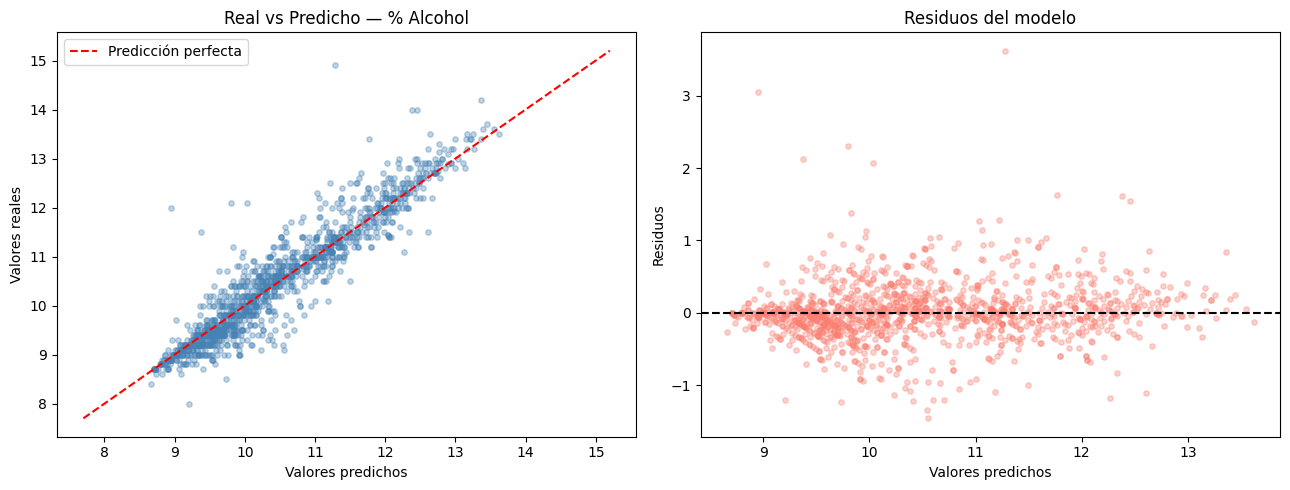

In [18]:
# Análisis de errores — gráfico real vs predicho
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Real vs predicho
axes[0].scatter(y_pred_reg, y_test_reg, alpha=0.35, color="steelblue", s=15)
lims = [min(y_test_reg.min(), y_pred_reg.min()) - 0.3,
        max(y_test_reg.max(), y_pred_reg.max()) + 0.3]
axes[0].plot(lims, lims, "r--", label="Predicción perfecta")
axes[0].set_xlabel("Valores predichos")
axes[0].set_ylabel("Valores reales")
axes[0].set_title("Real vs Predicho — % Alcohol")
axes[0].legend()

# Residuos
residuos = y_test_reg.values - y_pred_reg
axes[1].scatter(y_pred_reg, residuos, alpha=0.35, color="salmon", s=15)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Valores predichos")
axes[1].set_ylabel("Residuos")
axes[1].set_title("Residuos del modelo")

plt.tight_layout()
plt.show()

**Análisis de errores — Regresión:**

El modelo de Random Forest consigue un MAPE bastante bajo, lo que significa que se equivoca en media un porcentaje pequeño sobre el grado real del vino.

En la gráfica real vs predicho se puede ver que el modelo funciona bien en el rango central (9-13%) pero tiene algo más de dispersión en los valores extremos, especialmente vinos con grado muy bajo o muy alto donde hay menos datos de entrenamiento.

Los residuos no muestran un patrón sistemático claro, lo que es buena señal.

En producción habría que avisar al cliente de que las predicciones para vinos con grados muy atípicos (por debajo de 9 o por encima de 13) pueden ser menos fiables.